In [2]:
#Importations des bibliotheques necessaires
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import missingno as msno
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import MissingIndicator, KNNImputer,SimpleImputer
from sklearn.impute import IterativeImputer
df = pd.read_csv('/content/Titanic.csv').set_index('PassengerId')

In [3]:
#Affissage des 5 premieres lignes
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Vue d'enssemble sur les colonnes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [5]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [6]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [7]:
df['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [8]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [9]:
df['Cabin'].value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [10]:
#Affissage des 5 dernieres lignes
df.tail()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [41]:
#Transformation des variable suivantes en var Categorielles
df['Survived']=df['Survived'].astype('category')
df['Sex']=df['Sex'].astype('category')
df['Embarked']=df['Embarked'].astype('category')
df['Pclass']=df['Pclass'].astype('category')

In [42]:
#Pour avoir une vue d'enssemble des colones de notre dataset et verifié si la modification fontionne
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Name      891 non-null    object  
 3   Sex       891 non-null    category
 4   Age       891 non-null    float64 
 5   SibSp     891 non-null    int64   
 6   Parch     891 non-null    int64   
 7   Ticket    891 non-null    object  
 8   Fare      891 non-null    float64 
 9   Cabin     891 non-null    object  
 10  Embarked  891 non-null    category
 11  Pclss     891 non-null    category
dtypes: category(5), float64(2), int64(2), object(3)
memory usage: 93.0+ KB


In [43]:
#Stat descriptive des variables numerique ou quantitatives
df.describe()

,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000
mean,29.361582,0.523008,0.381594,32.204208
std,13.019697,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,35.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


In [14]:
#stat descriptives des variable categoriels ou quanlitatives
df.describe(include='category')

,Survived,Sex,Embarked
count,891,891,889
unique,2,2,3
top,0,male,S
freq,549,577,644


In [15]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [16]:
#cherchons si il y'a de valeures manquantes dans notre dataset
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


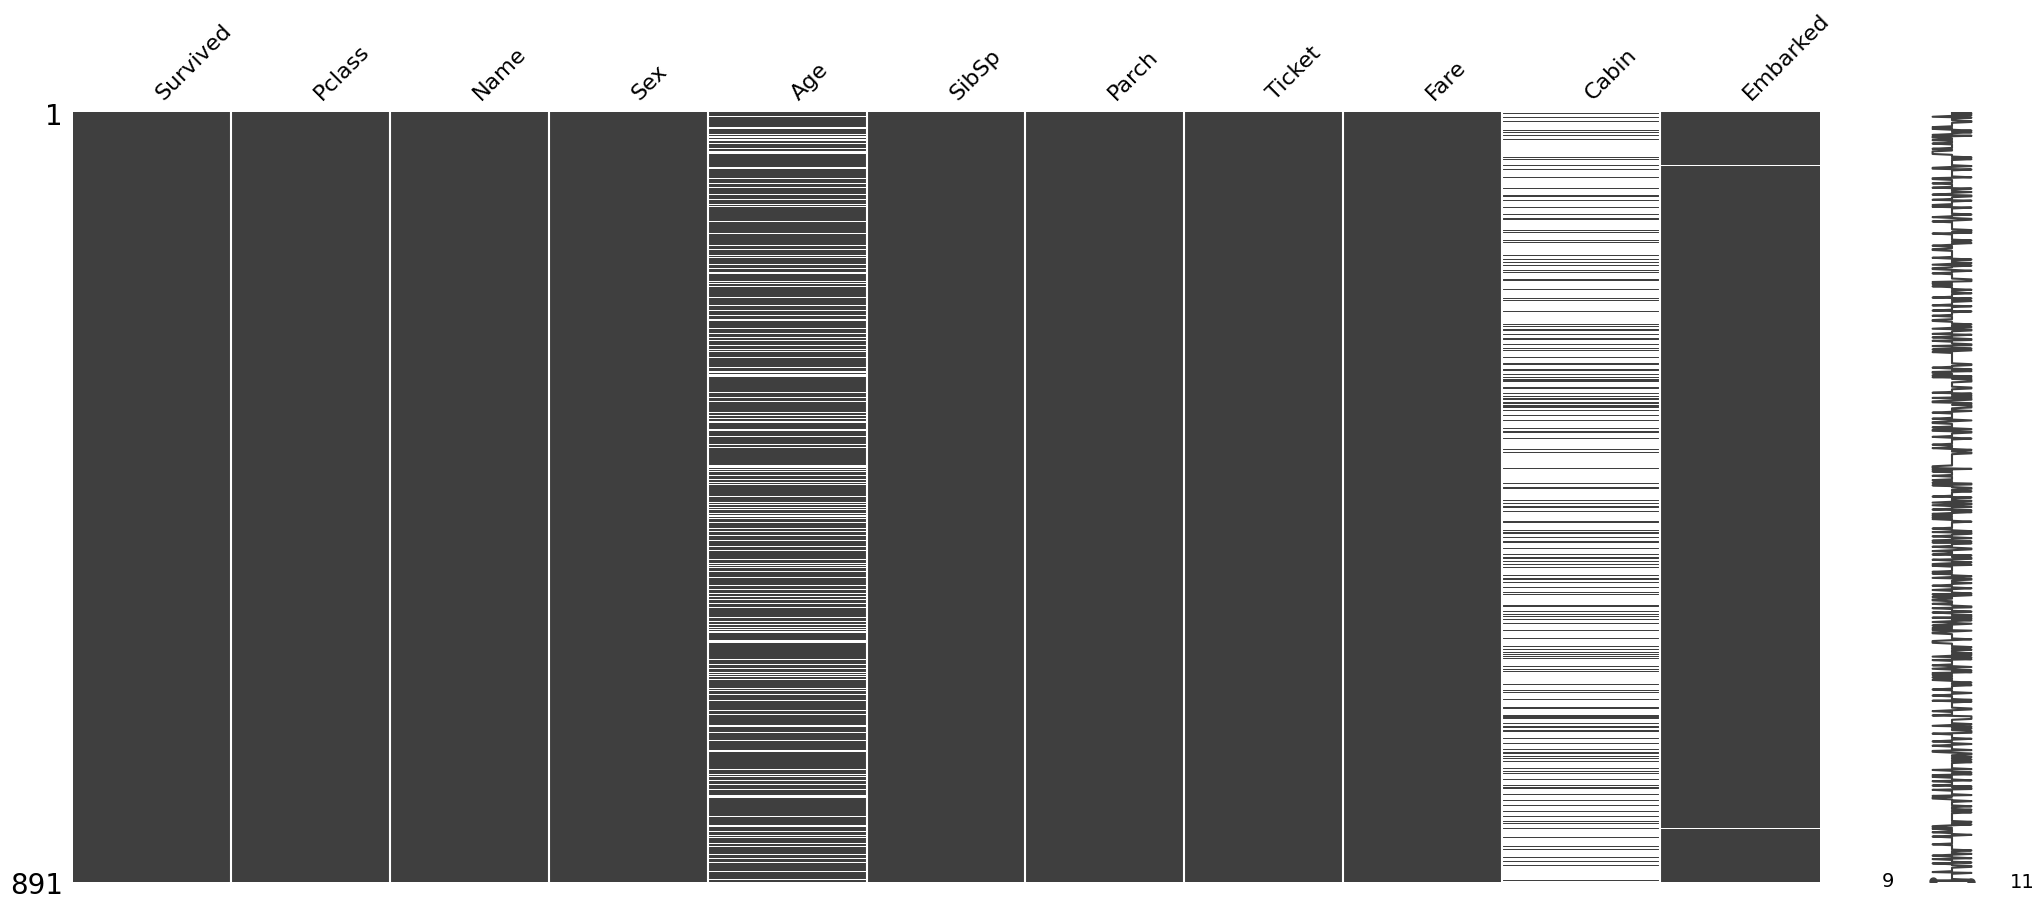

In [17]:
# Visualiser les valeurs manquantes avec missingno
msno.matrix(df)
plt.show()

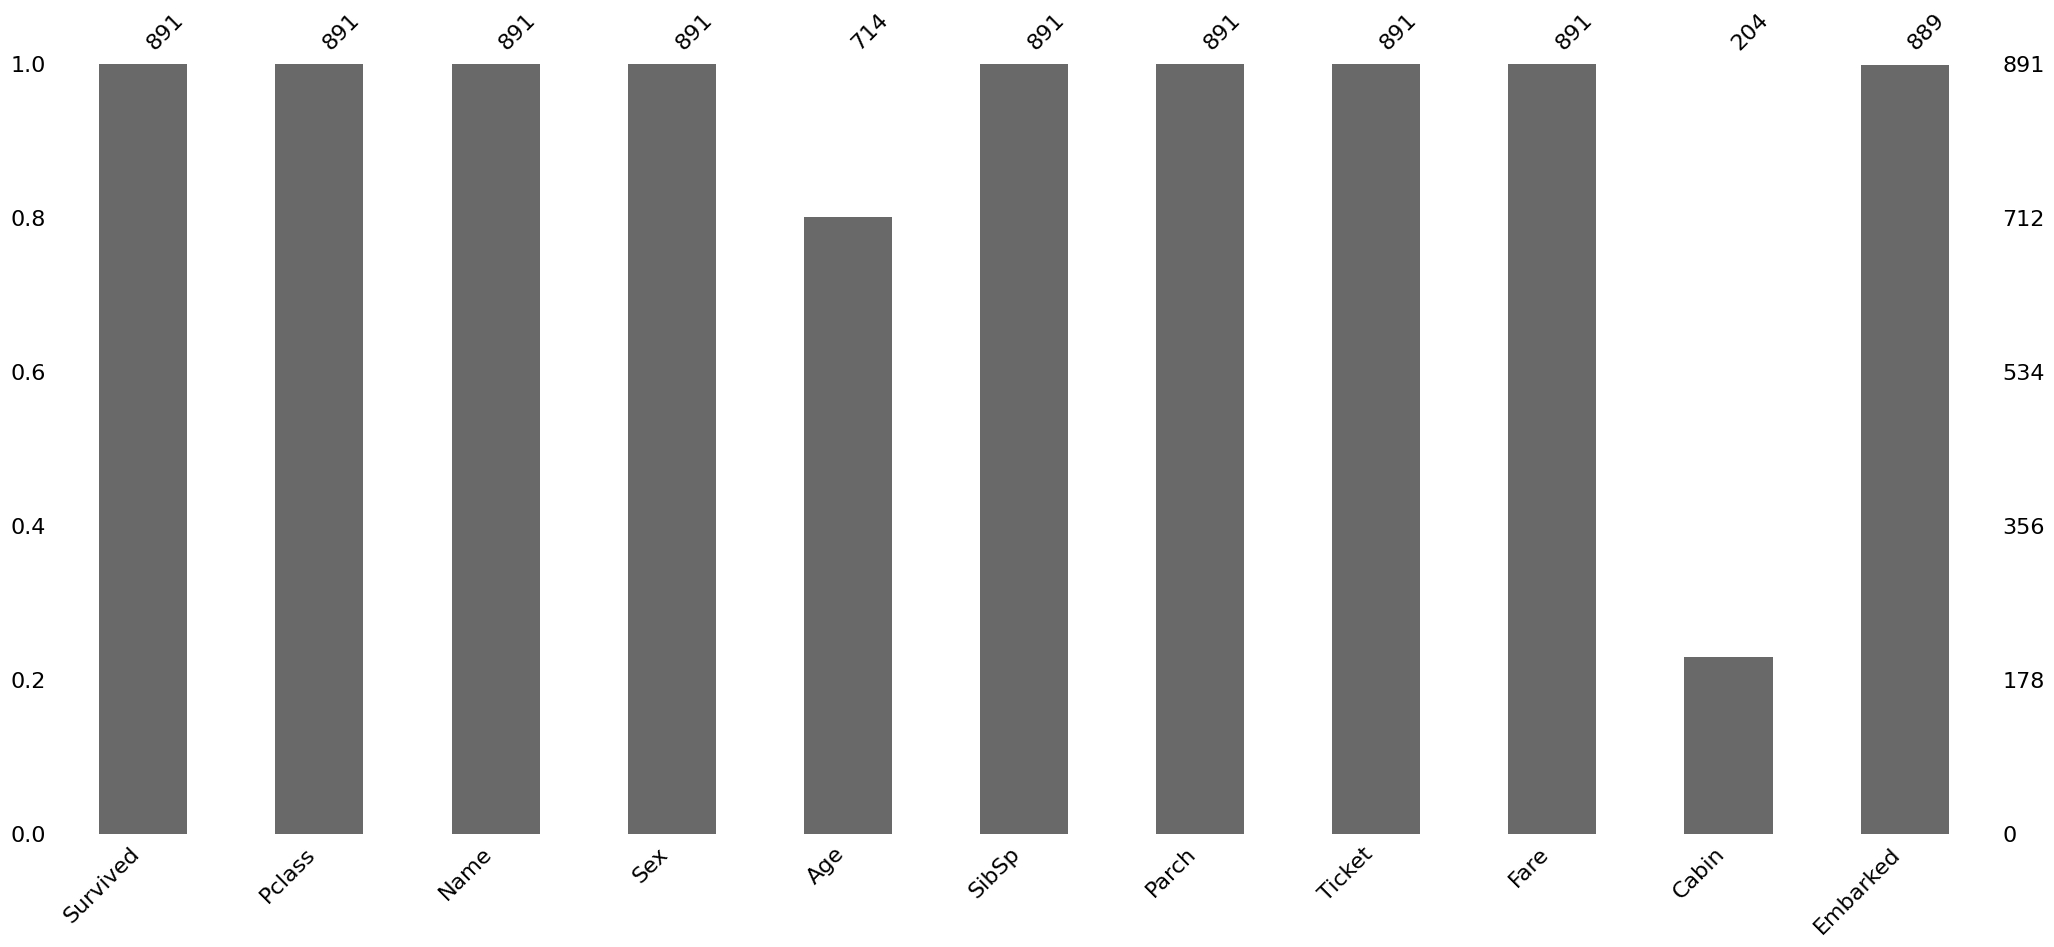

In [18]:
#Diagramme en bar pour identifier les valeures manquantes
msno.bar(df)
plt.show()

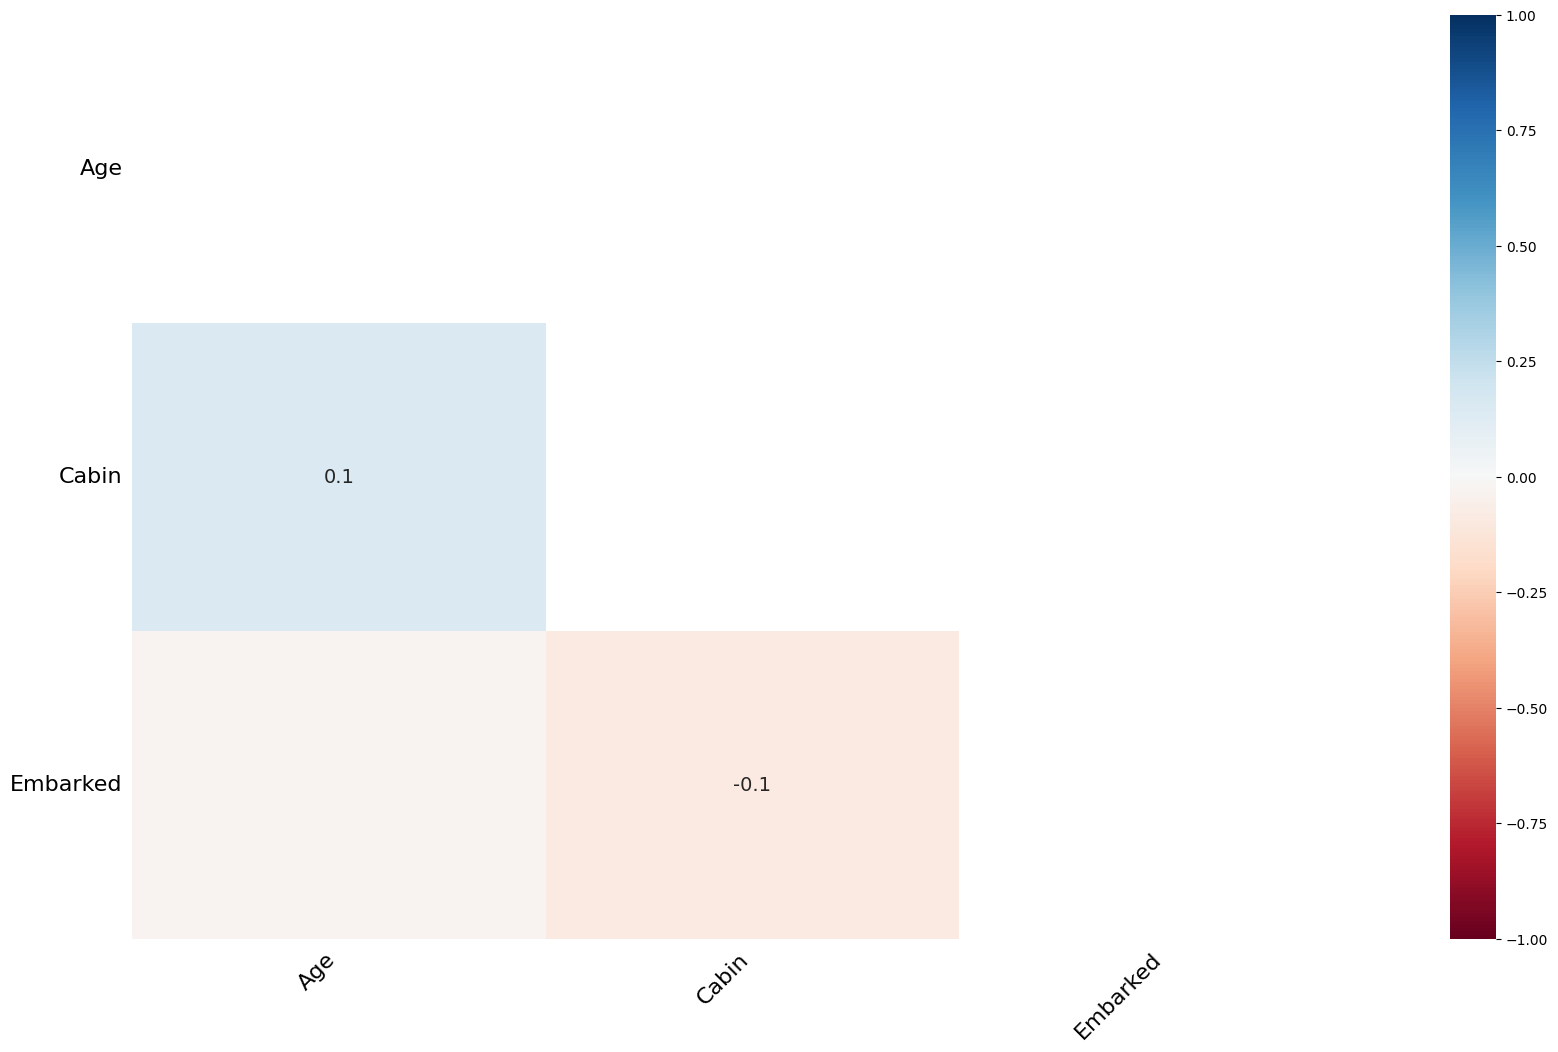

In [19]:
#Matrice de correlation des valeures manquantes
msno.heatmap(df)
plt.show()

In [20]:
# Tableau des valeurs manquantes par colonne
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_table = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percent})
print(missing_table)

          Missing Values  Percentage
Survived               0    0.000000
Pclass                 0    0.000000
Name                   0    0.000000
Sex                    0    0.000000
Age                  177   19.865320
SibSp                  0    0.000000
Parch                  0    0.000000
Ticket                 0    0.000000
Fare                   0    0.000000
Cabin                687   77.104377
Embarked               2    0.224467


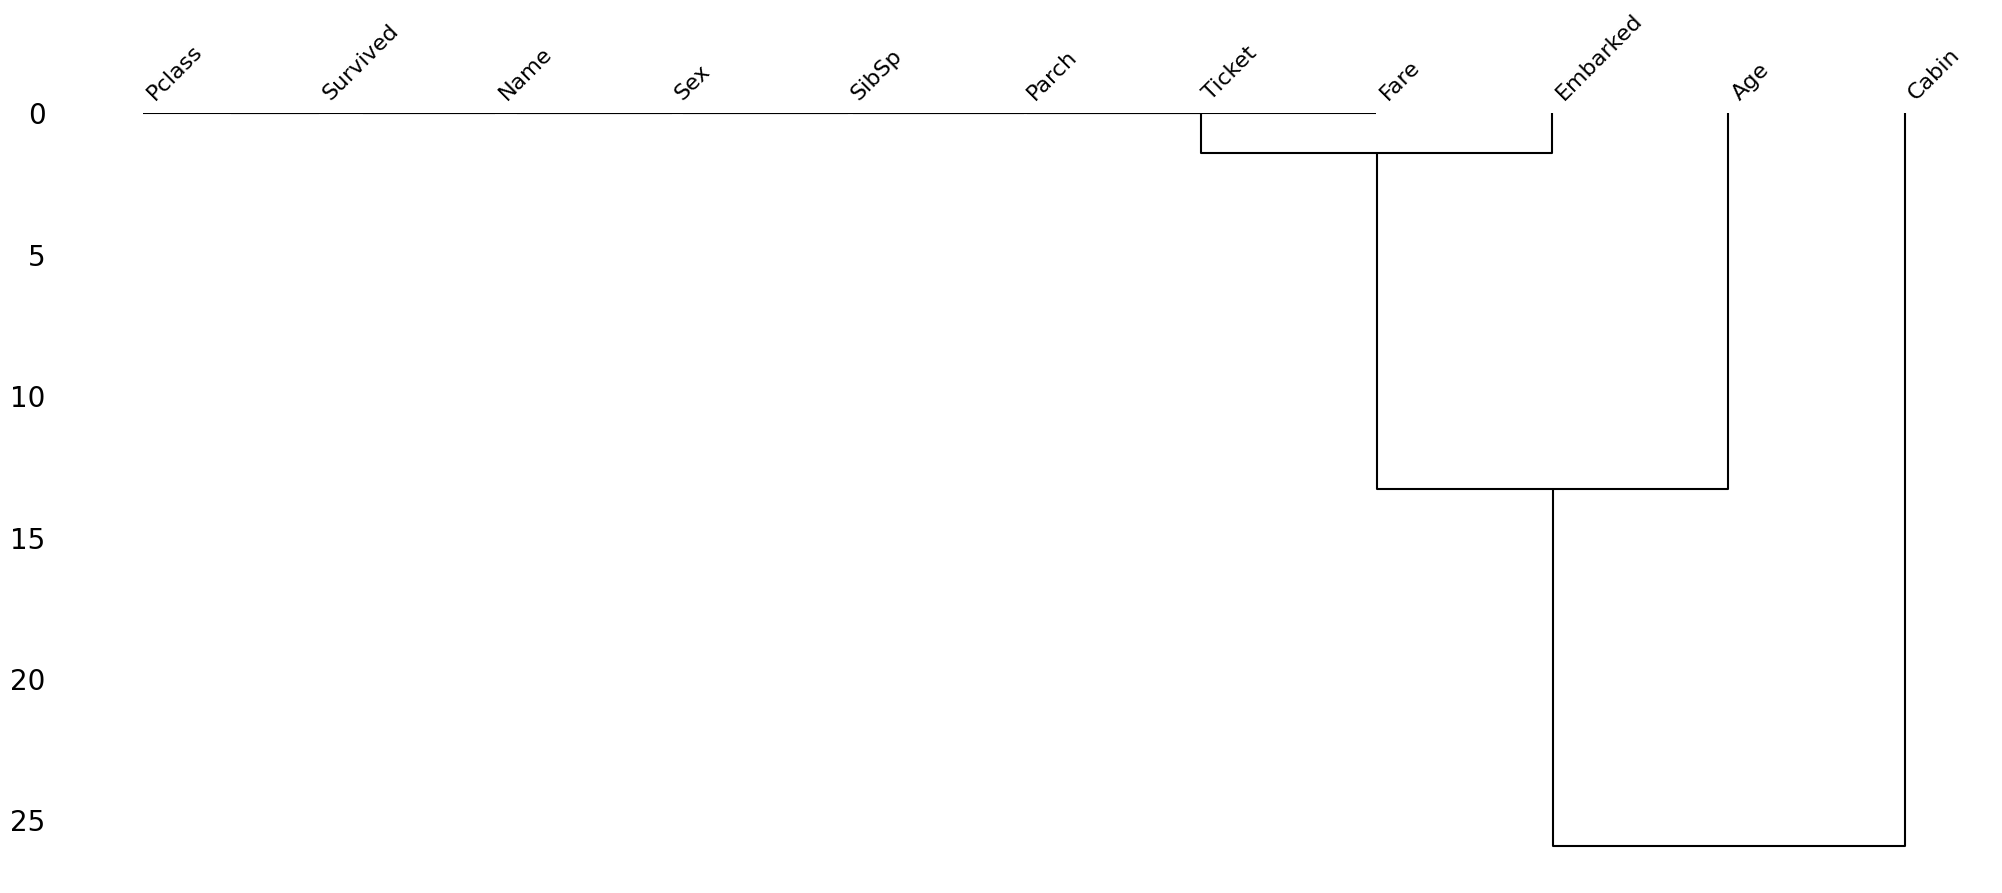

In [21]:
# Analyser la corrélation entre les valeurs manquantes
msno.dendrogram(df)
plt.show()

In [22]:
#Traitement des valeurs manquantes des variable quantitatives en les remplacant par la moyenne
imputer_median = SimpleImputer(strategy='median')
df['Age'] = imputer_median.fit_transform(df[['Age']])
df.isnull().mean()

,0
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.000000
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Cabin,0.771044


In [23]:
#Traitement des valeurs manquantes des variable qualitatives en les remplacant pas le mode
var_quali=['Cabin','Embarked']
imputer_mode = SimpleImputer(strategy='most_frequent')
df[var_quali]=imputer_mode.fit_transform(df[var_quali])
df.isnull().mode()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,False


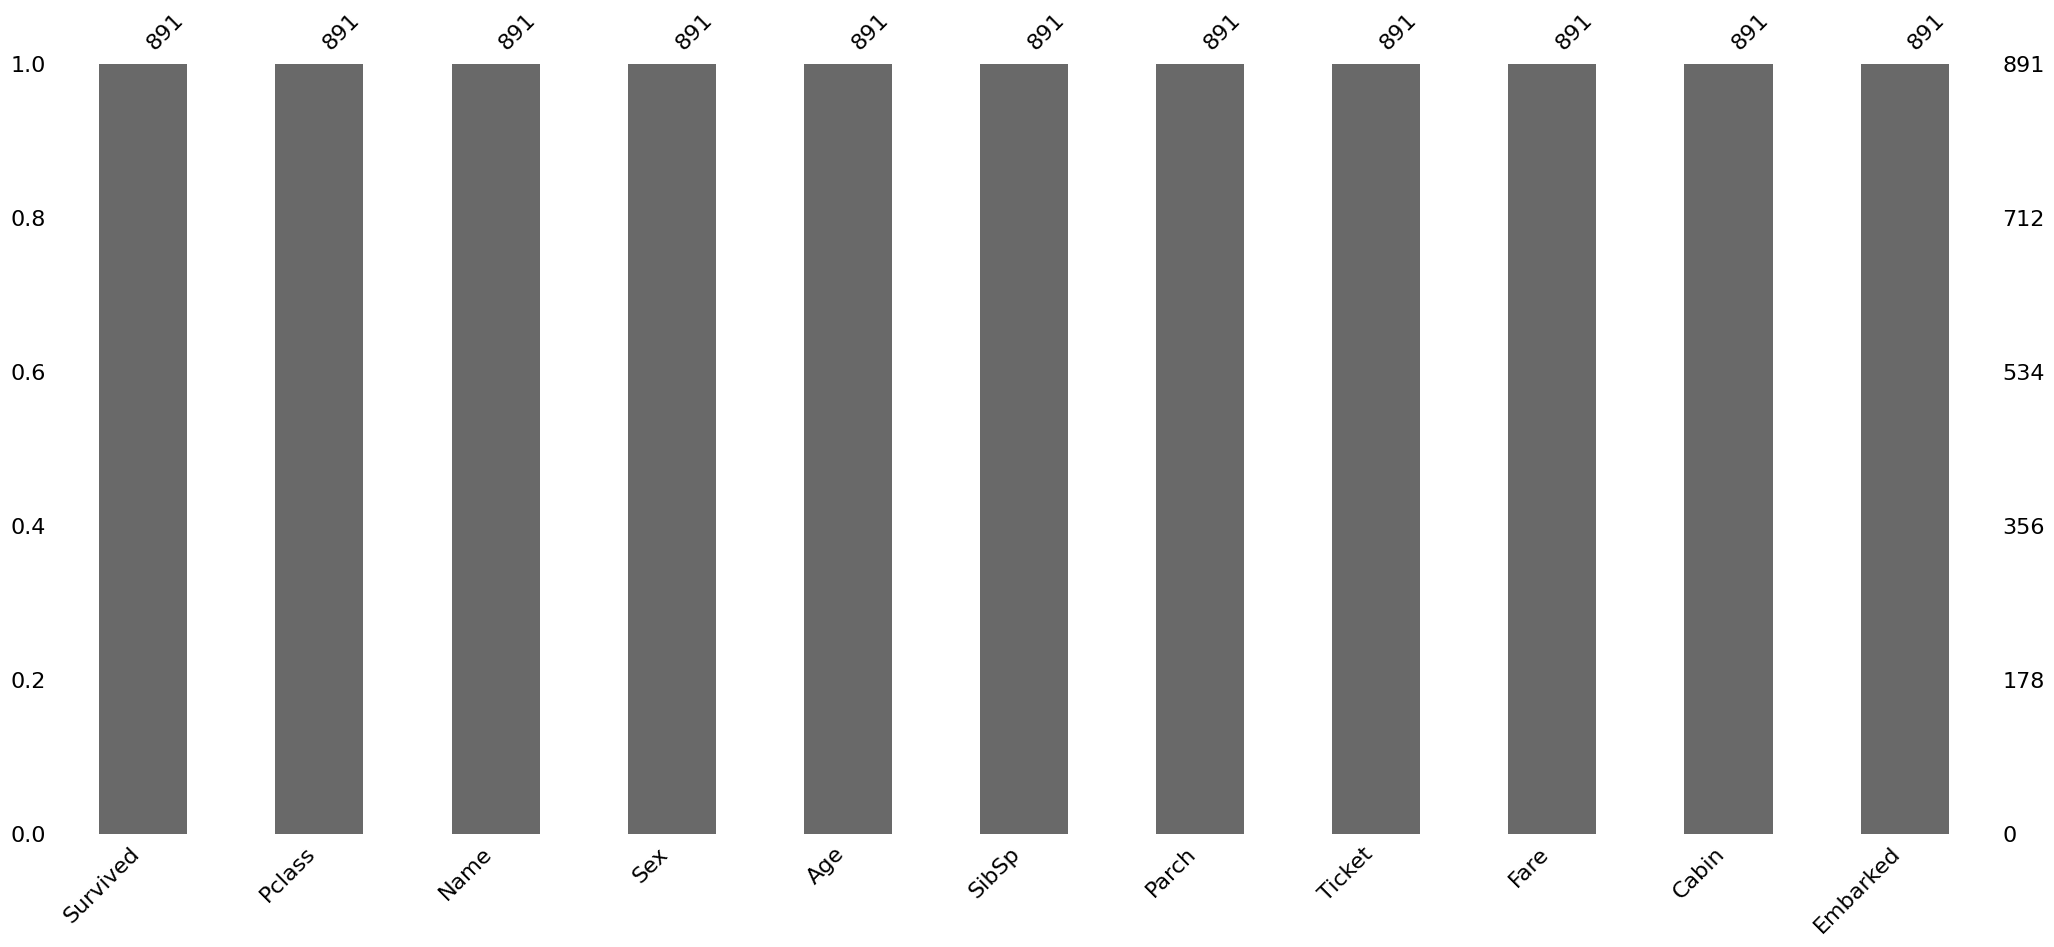

In [24]:
#Verifions si les valeurs manquante sont bien traités
msno.bar(df)
plt.show()

In [25]:
n=(df.dtypes == 'int64') | (df.dtypes == 'float64')
n

,0
Survived,False
Pclass,True
Name,False
Sex,False
Age,True
SibSp,True
Parch,True
Ticket,False
Fare,True
Cabin,False


In [26]:
# Grouper le DataFrame 'df' par la colonne 'Age'
# et calculer la moyenne de toutes les autres colonnes *numériques*.
df.groupby('Age').mean(numeric_only=True)

,Pclass,SibSp,Parch,Fare
Age,,,,
0.42,3.0,0.0,1.0,8.5167
0.67,2.0,1.0,1.0,14.5000
0.75,3.0,2.0,1.0,19.2583
0.83,2.0,0.5,1.5,23.8750
0.92,1.0,1.0,2.0,151.5500
...,...,...,...,...
70.00,1.5,0.5,0.5,40.7500
70.50,3.0,0.0,0.0,7.7500
71.00,1.0,0.0,0.0,42.0792


In [27]:
x=df.loc[:,['Pclass','Survived','Sex']]

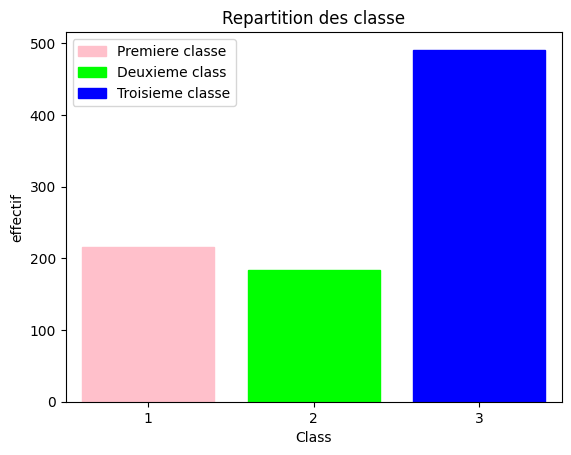

In [28]:
ax=sns.countplot(x='Pclass',data=df,label=['Premiere classe','Deuxieme class','Troisieme classe'])
plt.title('Repartition des classe')
plt.xlabel('Class')
plt.ylabel('effectif')
ax.patches[0].set_color('pink')
ax.patches[1].set_color('lime')
ax.patches[2].set_color('blue')
plt.legend()
plt.show()



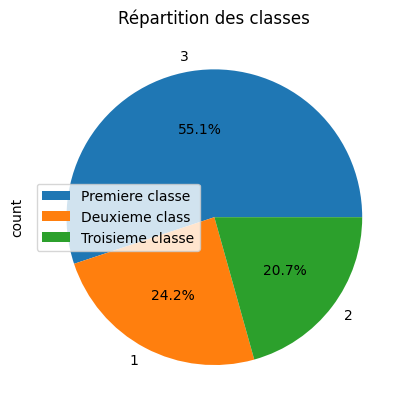

In [29]:
df['Pclass'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Répartition des classes')
label=['Premiere classe','Deuxieme class','Troisieme classe']
plt.legend(label)
plt.show()

/tmp/ipython-input-473388652.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x='Age',data=df, bins=20,palette='Set2',kde=True)


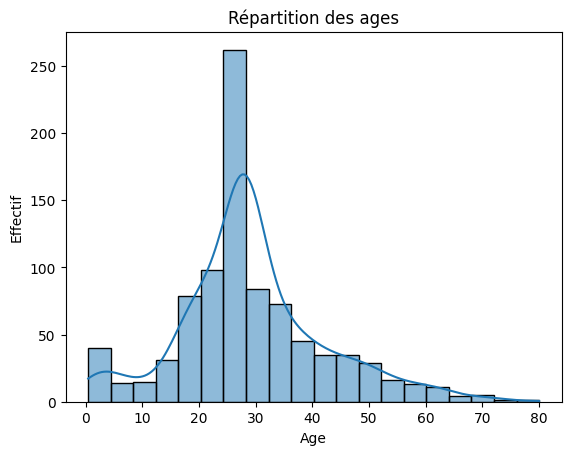

In [38]:
sns.histplot(x='Age',data=df, bins=20,palette='Set2',kde=True)
plt.title('Répartition des ages')
plt.xlabel('Age')
plt.ylabel('Effectif')
plt.title('Répartition des ages')
plt.show()

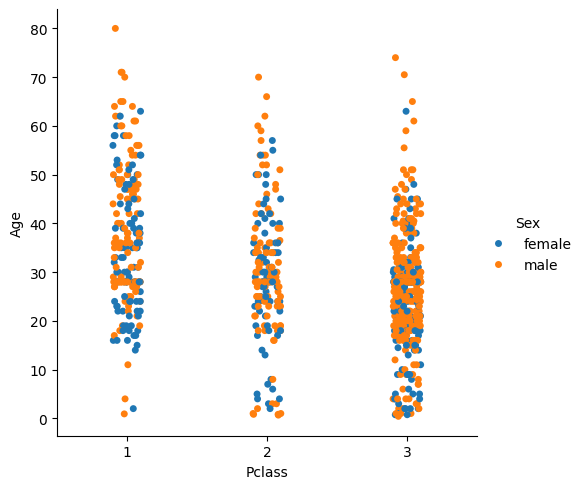

In [31]:
sns.catplot(x='Pclass',y='Age',data=df,hue='Sex')

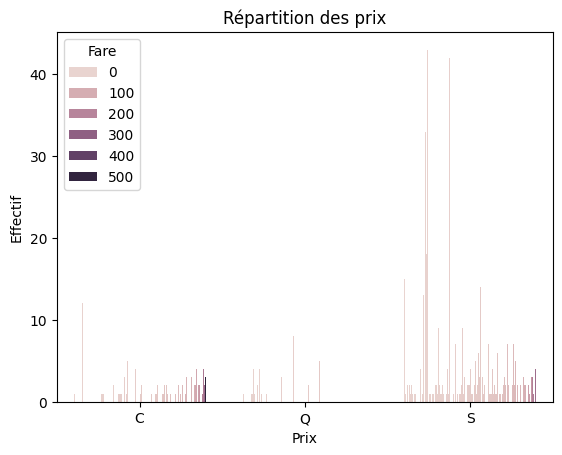

In [46]:
sns.countplot(x='Embarked',data=df,hue='Fare')
plt.title('Répartition des prix')
plt.xlabel('Prix')
plt.ylabel('Effectif')
plt.show()

In [32]:
w=df['Age'].max()
i=df['Age'].idxmax()
df.loc[i,'Sex']

'male'